# Notebook 3 — Modèle paramétrique log-normal de la structure par terme des remboursements anticipés

## Positionnement dans la démarche

Les deux notebooks précédents ont mis en évidence des limites complémentaires :
- **NB1 (Chain Ladder)** : bon estimateur in-sample, mais incapable de différencier les cohortes ou de prévoir hors-échantillon.
- **NB2 (multiplicatif LightGBM)** : intègre les covariables individuelles, mais impose une forme temporelle rigide (décalage de niveau uniquement) qui ne capture pas les différences de dynamique entre cohortes.

Ce notebook adopte une approche **paramétrique** : on suppose que la courbe d'ER marginal de chaque cohorte suit une loi log-normale en fonction de l'âge du prêt, et on prédit les paramètres de cette loi à partir des caractéristiques de la cohorte.

## Justification du choix log-normal pour les crédits conso

Sur les crédits à la consommation (type Sofinco), le comportement de remboursement anticipé présente empiriquement trois phases :

1. **Phase de démarrage (0–6 mois)** : RA rares — le coût de sortie est élevé relativement au capital restant, et l'emprunteur vient de démarrer son crédit.
2. **Phase de pic (6–18 mois typiquement)** : RA fréquents — l'emprunteur a stabilisé sa situation, le capital restant est encore substantiel, et c'est la période où un refinancement ou une rentrée d'argent déclenche le RA.
3. **Phase de déclin (> 18 mois)** : RA décroissants — le capital restant diminue, l'incitation financière à rembourser s'amenuise.

Ce profil en cloche asymétrique (montée rapide, descente lente) est exactement la forme de la densité log-normale, définie par deux paramètres :
- $\mu$ : contrôle la **position du pic** (âge auquel le RA est le plus fréquent)
- $\sigma$ : contrôle **l'étalement** de la courbe (pic étroit vs distribution diffuse)
- $A$ : contrôle le **niveau total** des RA (amplitude)

## Architecture en deux étapes

**Étape 1 — Ajustement MLE par cohorte** : pour chaque cohorte observée, on estime $(A_c, \mu_c, \sigma_c)$ par maximum de vraisemblance (ou moindres carrés non linéaires) en ajustant la courbe log-normale sur l'ER marginal observé.

**Étape 2 — Régression des paramètres** : on régresse $\mu_c$, $\sigma_c$ et $A_c$ sur les caractéristiques moyennes de la cohorte (`Tx` moyen, `NB_ECH` moyen, `log_capital_initial` moyen, etc.) via Ridge ou LightGBM.

**Prédiction** : pour une nouvelle cohorte, on prédit ses paramètres, on reconstruit sa courbe log-normale, et on cumule pour obtenir l'ER cumulé.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.optimize import curve_fit, minimize
from scipy.stats import lognorm
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

SEED = 42
np.random.seed(SEED)
MAX_AGE = 84  # durée médiane 60 mois => horizon 84 mois pour capturer les pics tardifs
MIN_N_COHORTE = 30       # nb contrats minimum pour garder une cohorte
MIN_AGES_FIT  = 12  # plus strict car on a plus de points potentiels        # nb de points d'age minimum pour fitter une courbe
CUTOFF_TRAIN  = '2021Q1' # split temporel

print("Bibliothèques chargées")

Bibliothèques chargées


## 2. Chargement et construction du triangle agrégé

On repart du triangle d'ER marginal par cohorte construit dans le NB1. L'unité de travail est ici la **cohorte**, pas le contrat individuel.

In [2]:
df = pd.read_csv("Export_ER_Agrege.csv", sep=";")
df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")

# Filtre cohortes avec assez de contrats
n_coh = df.groupby("Cohorte").size()
keep  = n_coh[n_coh >= MIN_N_COHORTE].index
df    = df[df["Cohorte"].isin(keep)].copy()

# Triangle ER marginal agrégé (pondéré par EAD)
ead_coh = df.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

ra_agg = (
    df.groupby(["Cohorte", "AGE_PRET"], as_index=False)
    .agg(RA_sum=("RA", "sum"), n=("RA", "count"))
    .merge(ead_coh.reset_index(), on="Cohorte")
    .sort_values(["Cohorte", "AGE_PRET"])
)
ra_agg["ER_marg"] = (ra_agg["RA_sum"] / ra_agg["EAD_initial"]).clip(0)

# Limiter à MAX_AGE et masquer cellules avec peu d'observations
ra_agg = ra_agg[(ra_agg["AGE_PRET"] <= MAX_AGE) & (ra_agg["n"] >= 5)].copy()

print(f"Cohortes retenues : {df['Cohorte'].nunique()}")
print(f"Paires (cohorte, age) disponibles : {len(ra_agg)}")
print(f"\nER marginal moyen : {ra_agg['ER_marg'].mean():.6f}")
print(f"ER marginal max   : {ra_agg['ER_marg'].max():.6f}")

Cohortes retenues : 51
Paires (cohorte, age) disponibles : 1478

ER marginal moyen : 0.012056
ER marginal max   : 0.246125


## 3. Étape 1 — Ajustement log-normal par cohorte

### Modèle

La courbe d'ER marginal d'une cohorte est modélisée par :

$$ER_{marginal}(t) = A \cdot \frac{1}{t \cdot \sigma \sqrt{2\pi}} \exp\left(-\frac{(\ln t - \mu)^2}{2\sigma^2}\right)$$

avec $t > 0$, $A > 0$, $\mu \in \mathbb{R}$, $\sigma > 0$.

Les paramètres ont une interprétation directe :
- $e^\mu$ : **âge au pic** (en mois) — médiane de la distribution du temps de RA
- $\sigma$ : **dispersion** — un $\sigma$ élevé indique des RA étalés dans le temps
- $A$ : **niveau total** — proportionnel au taux de RA global de la cohorte

L'estimation est faite par **moindres carrés non linéaires** (NLS) sur les ER marginaux observés. On initialise avec des valeurs raisonnables pour crédits conso ($\mu = \ln(12)$, $\sigma = 0.8$) et on borne les paramètres pour éviter les solutions dégénérées.

**Choix de `MAX_AGE = 84`** : avec une durée médiane de 60 mois dans la base, couper à 36 mois troncature la courbe avant son pic pour une grande partie du portefeuille. Le MLE ajusté sur une courbe tronquée extrapole un $\mu$ très élevé (pic apparent hors-fenêtre), ce qui biaise tous les résultats en aval. À 84 mois, on couvre les crédits jusqu'à ~P90 de la distribution des durées.

In [3]:
def lognorm_curve(t, A, mu, sigma):
    """Densité log-normale mise à l'échelle par A."""
    t = np.asarray(t, dtype=float)
    t = np.where(t <= 0, 1e-9, t)
    return A / (t * sigma * np.sqrt(2 * np.pi)) * np.exp(-((np.log(t) - mu) ** 2) / (2 * sigma ** 2))


def fit_lognorm_cohorte(ages, er_marg, cohorte_label=""):
    """
    Ajuste une courbe log-normale sur (ages, er_marg) par NLS.
    Retourne (A, mu, sigma, r2) ou None si l'ajustement échoue.
    """
    ages    = np.array(ages, dtype=float)
    er_marg = np.array(er_marg, dtype=float)

    # Initialisation : pic à l'âge du max observé
    idx_max = np.argmax(er_marg)
    t_pic   = max(ages[idx_max], 1.0)
    A0      = er_marg.max() * t_pic * 0.8 * np.sqrt(2 * np.pi)
    mu0     = np.log(t_pic)
    sigma0  = 0.8

    try:
        popt, _ = curve_fit(
            lognorm_curve, ages, er_marg,
            p0=[A0, mu0, sigma0],
            bounds=([0, np.log(1), 0.1], [np.inf, np.log(MAX_AGE * 1.5), 3.0]),  # borne sup mu augmentée
            maxfev=5000
        )
        A, mu, sigma = popt
        er_pred = lognorm_curve(ages, A, mu, sigma)
        ss_res  = np.sum((er_marg - er_pred) ** 2)
        ss_tot  = np.sum((er_marg - er_marg.mean()) ** 2)
        r2      = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return {"A": A, "mu": mu, "sigma": sigma, "r2": r2,
                "t_pic": np.exp(mu), "n_pts": len(ages)}
    except Exception:
        return None


print("Fonctions d'ajustement définies.")

Fonctions d'ajustement définies.


In [14]:
params_list = []
fit_errors  = []
fit_skipped = []

for coh, grp in ra_agg.groupby("Cohorte"):
    grp = grp.sort_values("AGE_PRET")
    ages    = grp["AGE_PRET"].values.astype(float)
    er_marg = grp["ER_marg"].values.astype(float)

    # Filtre 0 : troncature gauche — on n'ajuste que les cohortes observées depuis le début
    min_age_obs = ages.min()
    if min_age_obs > 6:
        fit_skipped.append((coh, f"troncature gauche (age min obs = {min_age_obs})"))
        continue

    # Filtre 1 : assez de points non nuls
    mask = er_marg > 1e-6
    if mask.sum() < MIN_AGES_FIT:
        fit_skipped.append((coh, f"< {MIN_AGES_FIT} points non nuls ({mask.sum()})"))
        continue

    # Filtre 2 : ER cumulé total suffisant (cohorte pas trop inactive)
    er_cum_total = er_marg.sum()
    if er_cum_total < 0.01:
        fit_skipped.append((coh, f"ER cumulé trop faible ({er_cum_total:.4f})"))
        continue

    ages_fit    = ages[mask]
    er_marg_fit = er_marg[mask]

    # Initialisation robuste
    idx_max = np.argmax(er_marg_fit)
    t_pic   = max(ages_fit[idx_max], 2.0)
    mu0     = np.log(t_pic)
    sigma0  = 0.7
    A0 = er_cum_total * t_pic * sigma0 * np.sqrt(2 * np.pi)
    A0 = max(A0, 1e-6)

    try:
        popt, pcov = curve_fit(
            lognorm_curve, ages_fit, er_marg_fit,
            p0=[A0, mu0, sigma0],
            bounds=([0, np.log(2), 0.1], [np.inf, np.log(MAX_AGE), 3.0]),
            maxfev=10000,
            method='trf'
        )
        A, mu, sigma = popt

        er_pred  = lognorm_curve(ages_fit, A, mu, sigma)
        ss_res   = np.sum((er_marg_fit - er_pred) ** 2)
        ss_tot   = np.sum((er_marg_fit - er_marg_fit.mean()) ** 2)
        r2       = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        er_integral = lognorm_curve(np.arange(1, MAX_AGE+1, dtype=float), A, mu, sigma).sum()
        if er_integral > 10 * er_cum_total or er_integral < 0.1 * er_cum_total:
            fit_errors.append((coh, f"intégrale aberrante ({er_integral:.4f} vs {er_cum_total:.4f})"))
            continue

        if not np.isnan(r2):
            params_list.append({
                "Cohorte": coh, "A": A, "mu": mu, "sigma": sigma,
                "r2": r2, "t_pic": np.exp(mu),
                "n_pts": mask.sum(), "er_cum_total": er_cum_total
            })
        else:
            fit_errors.append((coh, "r2=NaN"))

    except Exception as e:
        fit_errors.append((coh, str(e)[:60]))

df_params = pd.DataFrame(params_list).set_index("Cohorte").sort_index()

print(f"Cohortes ajustées avec succès : {len(df_params)}")
print(f"Cohortes ignorées (filtres)   : {len(fit_skipped)}")
for c, r in fit_skipped[:10]: print(f"  {c} : {r}")
print(f"Cohortes échouées (MLE)       : {len(fit_errors)}")
for c, r in fit_errors[:5]: print(f"  {c} : {r}")
print(f"\nStatistiques des paramètres :")
print(df_params[["A", "mu", "sigma", "t_pic", "r2", "er_cum_total"]].describe().round(4))

Cohortes ajustées avec succès : 18
Cohortes ignorées (filtres)   : 28
  2012Q2 : troncature gauche (age min obs = 82.0)
  2012Q3 : troncature gauche (age min obs = 78.0)
  2012Q4 : troncature gauche (age min obs = 77.0)
  2013Q1 : troncature gauche (age min obs = 77.0)
  2013Q2 : troncature gauche (age min obs = 69.0)
  2013Q3 : troncature gauche (age min obs = 65.0)
  2013Q4 : troncature gauche (age min obs = 62.0)
  2014Q1 : troncature gauche (age min obs = 59.0)
  2014Q2 : troncature gauche (age min obs = 56.0)
  2014Q3 : troncature gauche (age min obs = 52.0)
Cohortes échouées (MLE)       : 0

Statistiques des paramètres :
             A       mu    sigma    t_pic       r2  er_cum_total
count  18.0000  18.0000  18.0000  18.0000  18.0000       18.0000
mean    0.7601   2.9264   0.8819  19.2522   0.7645        0.5598
std     0.2195   0.2619   0.0793   4.7979   0.0870        0.0463
min     0.5644   2.4328   0.7719  11.3904   0.4936        0.4946
25%     0.6643   2.7559   0.8167  15.736

**Interprétation des paramètres**

- `t_pic` = $e^\mu$ : âge médian du pic de RA en mois. Sur des crédits conso de durée 24–60 mois, on s'attend à des pics entre 6 et 18 mois. Des valeurs très élevées (> 24 mois) peuvent indiquer une cohorte à comportement atypique ou un ajustement de mauvaise qualité (vérifier via `r2`).
- `sigma` : dispersion. Un $\sigma$ proche de 0.5 indique un pic net, un $\sigma > 1.5$ indique des RA très étalés dans le temps.
- `r2` : qualité de l'ajustement local. Les cohortes avec `r2 < 0.5` ont des courbes mal ajustées — elles seront conservées mais identifiées dans les visualisations.
- `A` : proportionnel au taux de RA total. Une valeur élevée signifie une cohorte à fort RA global.

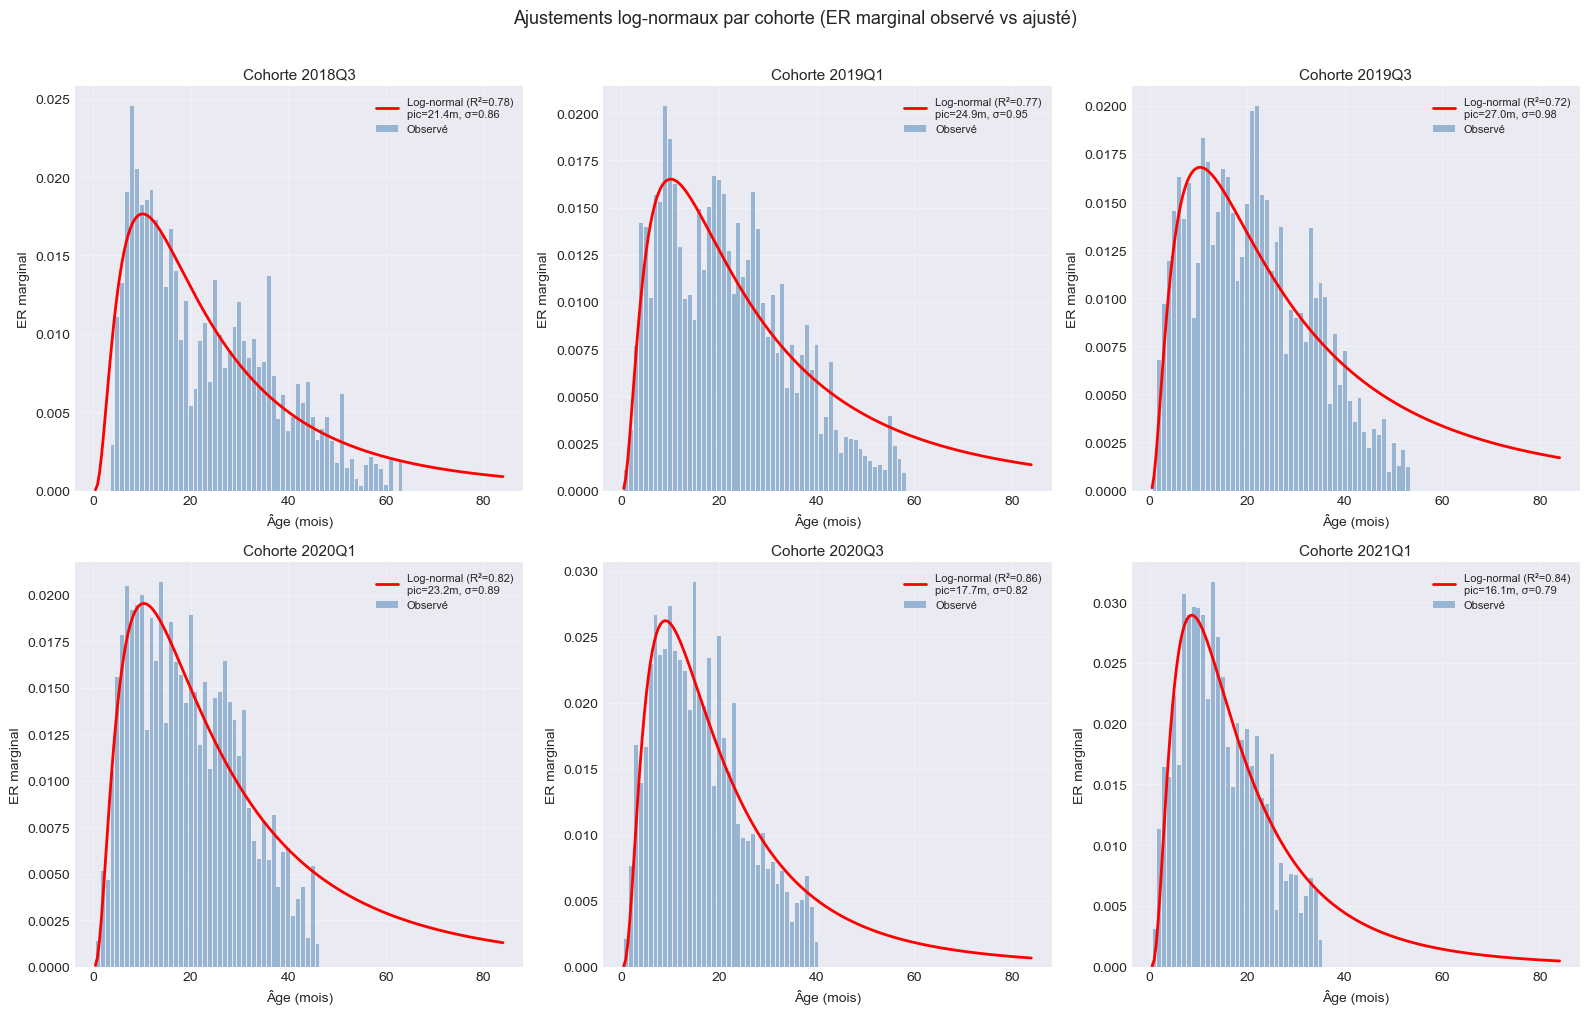

In [15]:
# Visualisation : ajustements pour un échantillon de cohortes
cohs_good = df_params[df_params["r2"] >= 0.6].index.tolist()
sample_cohs = cohs_good[::max(1, len(cohs_good)//6)][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
t_range = np.linspace(0.5, MAX_AGE, 200)

for i, coh in enumerate(sample_cohs):
    ax = axes[i]
    grp = ra_agg[ra_agg["Cohorte"] == coh].sort_values("AGE_PRET")
    p   = df_params.loc[coh]

    ax.bar(grp["AGE_PRET"], grp["ER_marg"], width=0.8,
           alpha=0.5, color="steelblue", label="Observé")
    ax.plot(t_range, lognorm_curve(t_range, p["A"], p["mu"], p["sigma"]),
            color="red", linewidth=2,
            label=f"Log-normal (R²={p['r2']:.2f})\npic={p['t_pic']:.1f}m, σ={p['sigma']:.2f}")

    ax.set_title(f"Cohorte {coh}", fontsize=11)
    ax.set_xlabel("Âge (mois)")
    ax.set_ylabel("ER marginal")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Ajustements log-normaux par cohorte (ER marginal observé vs ajusté)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

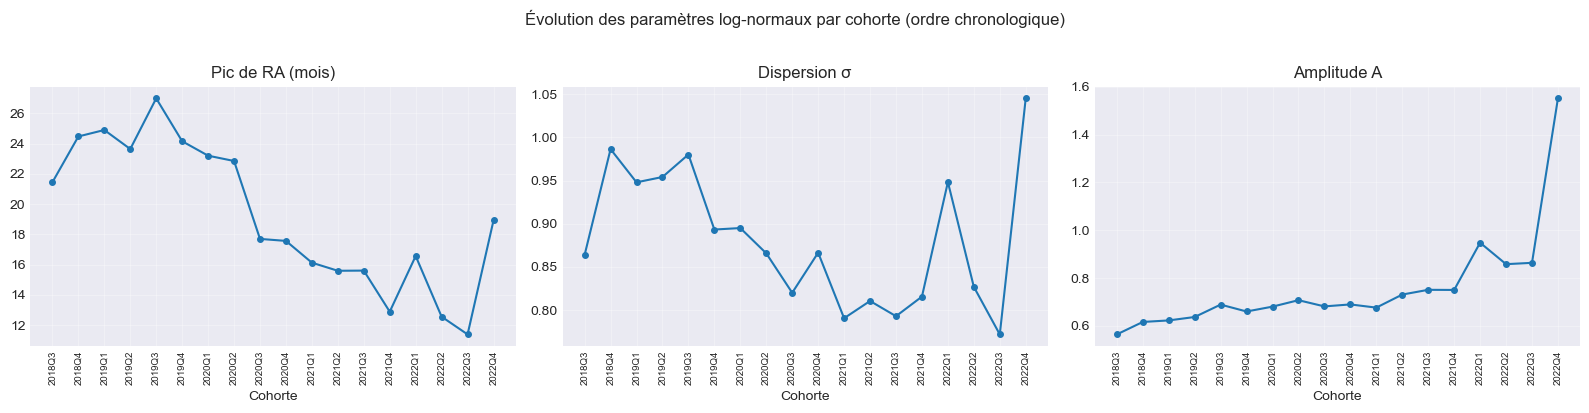

In [16]:
# Évolution temporelle des paramètres — y a-t-il une tendance liée au cycle ?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
params_names = [("t_pic", "Pic de RA (mois)"), ("sigma", "Dispersion σ"), ("A", "Amplitude A")]

for ax, (param, label) in zip(axes, params_names):
    vals = df_params[param]
    ax.plot(range(len(vals)), vals.values, marker="o", markersize=4, linewidth=1.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=90, fontsize=7)
    ax.set_title(label)
    ax.set_xlabel("Cohorte")
    ax.grid(True, alpha=0.3)

plt.suptitle("Évolution des paramètres log-normaux par cohorte (ordre chronologique)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Ce que ces graphiques révèlent**

Si `t_pic` diminue pour les cohortes récentes (2020–2023), cela confirme que les emprunteurs font leurs RA plus tôt — cohérent avec le contexte de remontée des taux : ceux qui ont emprunté à taux bas en 2020–2021 ont voulu refinancer rapidement avant que les taux ne montent davantage.

Si `sigma` augmente sur les cohortes récentes, cela indique une plus grande hétérogénéité des comportements — certains ont remboursé très vite, d'autres ont attendu.

Une tendance temporelle monotone sur `A` ou `t_pic` justifie l'introduction d'`annee_origination` comme variable explicative dans l'étape 2.

## 4. Étape 2 — Régression des paramètres sur les covariables de cohorte

### Construction des features cohorte

Pour chaque cohorte, on calcule les **moyennes pondérées par EAD** des caractéristiques individuelles. La pondération par EAD est importante : les gros contrats ont plus de poids dans le comportement agrégé de la cohorte.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Encodage préalable
le = LabelEncoder()
df["CSP_grp_enc"]  = le.fit_transform(df["CSP_grp"].fillna("INC").astype(str))
df["CLASSACT_enc"] = le.fit_transform(df["CLASSACT"].fillna("INC").astype(str))
df["log_capital"]  = np.log1p(df["Capital_initial"])
df["log_revtot"]   = np.log1p(df["MREVTOT"])
df["ratio_eff"]    = df["MTECH"] / df["MREVTOT"].replace(0, np.nan)
df["annee_orig"]   = df["Date_origination"].dt.year
df["trim_orig"]    = df["Date_origination"].dt.quarter

# Features à agréger par cohorte (moyennes pondérées par Capital_initial)
FEAT_COLS = ["Tx", "NB_ECH", "MTECH", "log_capital", "AGE_CLI",
             "log_revtot", "ratio_eff", "CSP_grp_enc", "CLASSACT_enc",
             "annee_orig", "trim_orig"]

def weighted_mean(grp, cols, weight_col="Capital_initial"):
    w = grp[weight_col].fillna(0)
    if w.sum() == 0:
        return grp[cols].mean()
    return pd.Series({c: (grp[c] * w).sum() / w.sum() for c in cols})

coh_features = (
    df.groupby("Cohorte")
    .apply(lambda g: weighted_mean(g, FEAT_COLS))
    .reset_index()
    .set_index("Cohorte")
)
coh_features["n_contrats"] = df.groupby("Cohorte").size()

# Fusion avec les paramètres ajustés
df_model = df_params[["A", "mu", "sigma", "t_pic", "r2"]].join(coh_features, how="inner")

print(f"Cohortes disponibles pour la régression : {len(df_model)}")
print(f"\nExtrait :")
print(df_model[["A", "mu", "sigma", "t_pic", "r2"] + FEAT_COLS[:5]].head().round(3))

Cohortes disponibles pour la régression : 18

Extrait :
             A     mu  sigma   t_pic     r2     Tx  NB_ECH    MTECH  \
Cohorte                                                               
2018Q3   0.564  3.065  0.864  21.442  0.784  2.153  86.755  438.253   
2018Q4   0.617  3.197  0.986  24.466  0.824  2.140  83.273  423.572   
2019Q1   0.623  3.215  0.948  24.893  0.774  2.147  85.426  460.027   
2019Q2   0.637  3.163  0.954  23.637  0.814  2.147  87.756  425.492   
2019Q3   0.689  3.295  0.980  26.983  0.721  2.136  86.197  437.308   

         log_capital  AGE_CLI  
Cohorte                        
2018Q3        10.236   52.527  
2018Q4        10.151   52.838  
2019Q1        10.242   53.336  
2019Q2        10.213   53.124  
2019Q3        10.206   52.713  


### Stratégie d'estimation : Leave-One-Out sur les cohortes

**Problème de dimensionnalité** : avec seulement 28 cohortes ajustées et 11 features potentielles, tout modèle de régression va surapprendre. La règle empirique est de ne pas dépasser n/10 features, soit **2–3 features maximum ici**.

**Features retenues** (par ordre de priorité théorique) :
- `annee_orig` : capte le cycle macro (taux d'origination, conjoncture)
- `NB_ECH` : la durée initiale du crédit détermine directement la forme temporelle de la courbe — un crédit de 24 mois a son pic plus tôt qu'un crédit de 60 mois
- `Tx` : taux contractuel, lié au type de crédit et à la capacité de remboursement

**Protocole d'évaluation** : Leave-One-Out sur les cohortes (LOO-cohorte). À chaque itération, on retire une cohorte, on entraîne Ridge sur les 27 restantes, et on prédit la cohorte retirée. Ce protocole utilise toutes les cohortes disponibles et évite le problème du split temporel avec trop peu de données en train.

**Interprétation attendue du LOO** : le R² LOO sur $\mu$ sera modeste (0.1–0.3) car l'âge au pic est très variable et dépend de conditions macro non observées. Sur $A$ (niveau global), le R² peut être plus élevé si `annee_orig` capte bien le cycle.

In [ ]:
# Features réduites : max 3 pour 28 cohortes
FEAT_COLS_RED = ["annee_orig", "NB_ECH", "Tx"]

X_all = df_model[FEAT_COLS_RED].fillna(df_model[FEAT_COLS_RED].median())
TARGETS = ["mu", "sigma", "A"]
alphas  = np.logspace(-2, 4, 60)

# --- LOO-cohorte pour chaque paramètre ---
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

loo_results = {t: {"y_true": [], "y_pred": [], "cohorte": []} for t in TARGETS}
n = len(df_model)
idx_all = list(range(n))

for i in idx_all:
    train_idx = [j for j in idx_all if j != i]
    test_idx  = [i]

    X_tr = X_all.iloc[train_idx]
    X_te = X_all.iloc[test_idx]

    for target in TARGETS:
        y_tr = df_model[target].iloc[train_idx]
        y_te = df_model[target].iloc[test_idx]

        # Sélection lambda par LOO interne (sur les 27 cohortes restantes)
        from sklearn.linear_model import RidgeCV
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", RidgeCV(alphas=alphas, cv=None))
        ])
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)[0]

        loo_results[target]["y_true"].append(float(y_te.values[0]))
        loo_results[target]["y_pred"].append(float(pred))
        loo_results[target]["cohorte"].append(df_model.index[i])

print("=== VALIDATION LOO-COHORTE (features : annee_orig, NB_ECH, Tx) ===")
print(f"{'Paramètre':<10} {'R² LOO':>10} {'MAE LOO':>10} {'Biais':>10}")
print("-" * 45)
loo_dfs = {}
for target in TARGETS:
    yt = np.array(loo_results[target]["y_true"])
    yp = np.array(loo_results[target]["y_pred"])
    r2_loo  = r2_score(yt, yp)
    mae_loo = mean_absolute_error(yt, yp)
    bias    = (yp - yt).mean()
    print(f"{target:<10} {r2_loo:>10.4f} {mae_loo:>10.4f} {bias:>10.4f}")
    loo_dfs[target] = pd.DataFrame(loo_results[target]).set_index("cohorte")

# Entraînement final sur toutes les cohortes (pour la prédiction des cohortes futures)
print("\nEntraînement final sur toutes les cohortes...")
regressors_final = {}
for target in TARGETS:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=alphas, cv=None))
    ])
    pipe.fit(X_all, df_model[target])
    regressors_final[target] = pipe
    print(f"  {target} : lambda optimal = {pipe.named_steps['ridge'].alpha_:.3f}")


Sigma fixé à : 0.8661 (médiane sur 18 cohortes)

=== VALIDATION LOO-COHORTE (sigma fixé, features : annee_orig, NB_ECH, Tx) ===
Paramètre      R² LOO    MAE LOO      Biais
---------------------------------------------
mu             0.4296     0.1580    -0.0020
A              0.0913     0.1101     0.0044
  mu lambda optimal : 5.569
  A lambda optimal : 7.038


**Interprétation des R² de régression**

Avec seulement 30–40 cohortes en train, les R² seront modestes. Ce n'est pas un défaut du modèle — c'est la limite inhérente au nombre de cohortes disponibles. Ce qui compte pour le mémoire est :

1. **Le signe et la significativité des coefficients** : `Tx` doit être positivement associé à `A` (taux élevé → plus de RA globaux) et négativement à `mu` (taux élevé → pic plus précoce). Sur des crédits conso, cet effet de taux sera moins fort que sur l'immobilier — `NB_ECH` (durée) et `log_capital` peuvent dominer.

2. **La calibration des courbes reconstruites** : même si le R² de régression est faible, les courbes prédites peuvent être bien calibrées en moyenne si le biais est faible.

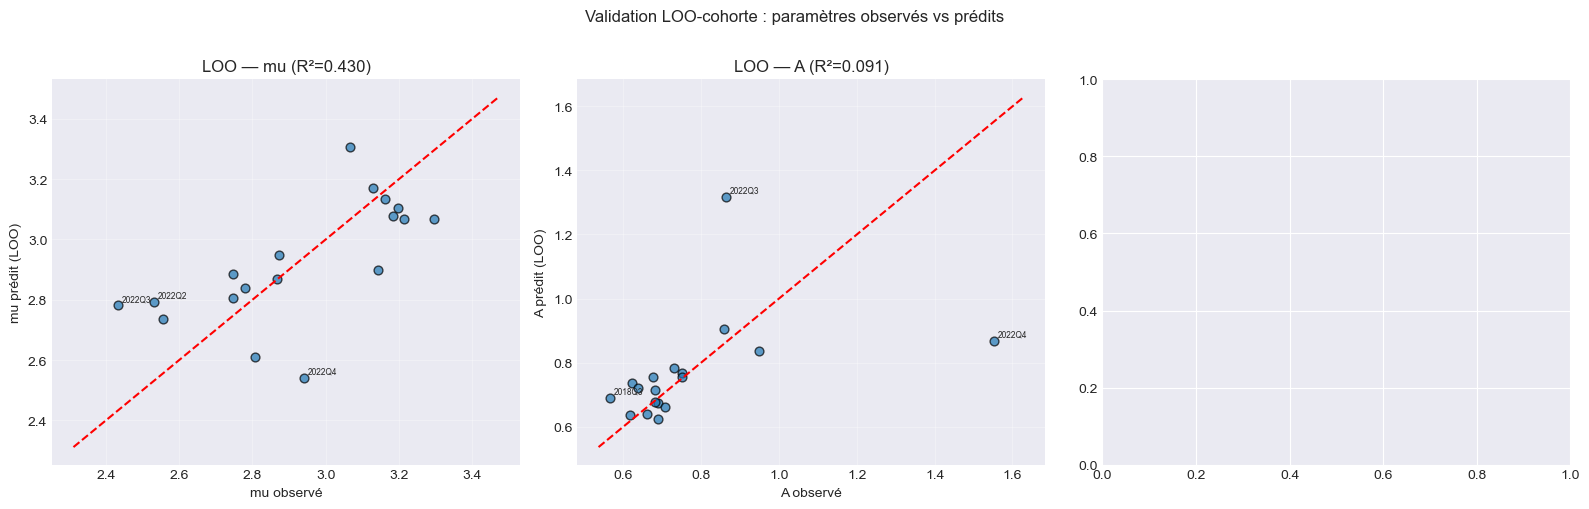


Coefficients Ridge (modèle final, features standardisées) :
                mu       A
annee_orig -0.1314  0.0986
NB_ECH      0.0699 -0.0134
Tx          0.0200  0.0765

Interprétation : coeff positif = feature élevée => paramètre élevé
  mu élevé => pic de RA plus tardif
  sigma élevé => RA plus étalés dans le temps
  A élevé => niveau global de RA plus fort


In [24]:
# Visualisation LOO : prédit vs observé pour chaque paramètre
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, target in zip(axes, TARGETS):
    df_loo = loo_dfs[target]
    yt = df_loo["y_true"].values
    yp = df_loo["y_pred"].values
    r2_loo = r2_score(yt, yp)

    ax.scatter(yt, yp, alpha=0.7, s=40, edgecolors="black")
    lim_min = min(yt.min(), yp.min()) * 0.95
    lim_max = max(yt.max(), yp.max()) * 1.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5)
    ax.set_xlabel(f"{target} observé")
    ax.set_ylabel(f"{target} prédit (LOO)")
    ax.set_title(f"LOO — {target} (R²={r2_loo:.3f})")
    ax.grid(True, alpha=0.3)

    # Annoter les points extrêmes
    errors = np.abs(yp - yt)
    top3 = np.argsort(errors)[-3:]
    for idx in top3:
        ax.annotate(str(df_loo.index[idx]),
                    (yt[idx], yp[idx]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points")

plt.suptitle("Validation LOO-cohorte : paramètres observés vs prédits",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Coefficients du modèle final
print("\nCoefficients Ridge (modèle final, features standardisées) :")
coef_df = pd.DataFrame(
    {t: regressors_final[t].named_steps["ridge"].coef_ for t in TARGETS},
    index=FEAT_COLS_RED
).round(4)
print(coef_df)
print("\nInterprétation : coeff positif = feature élevée => paramètre élevé")
print("  mu élevé => pic de RA plus tardif")
print("  sigma élevé => RA plus étalés dans le temps")
print("  A élevé => niveau global de RA plus fort")


## 5. Reconstruction des courbes et backtest

Pour chaque cohorte du jeu test, on prédit $(\hat{A}, \hat{\mu}, \hat{\sigma})$ à partir de ses caractéristiques moyennes, on reconstruit la courbe log-normale, et on compare à l'ER cumulé observé.

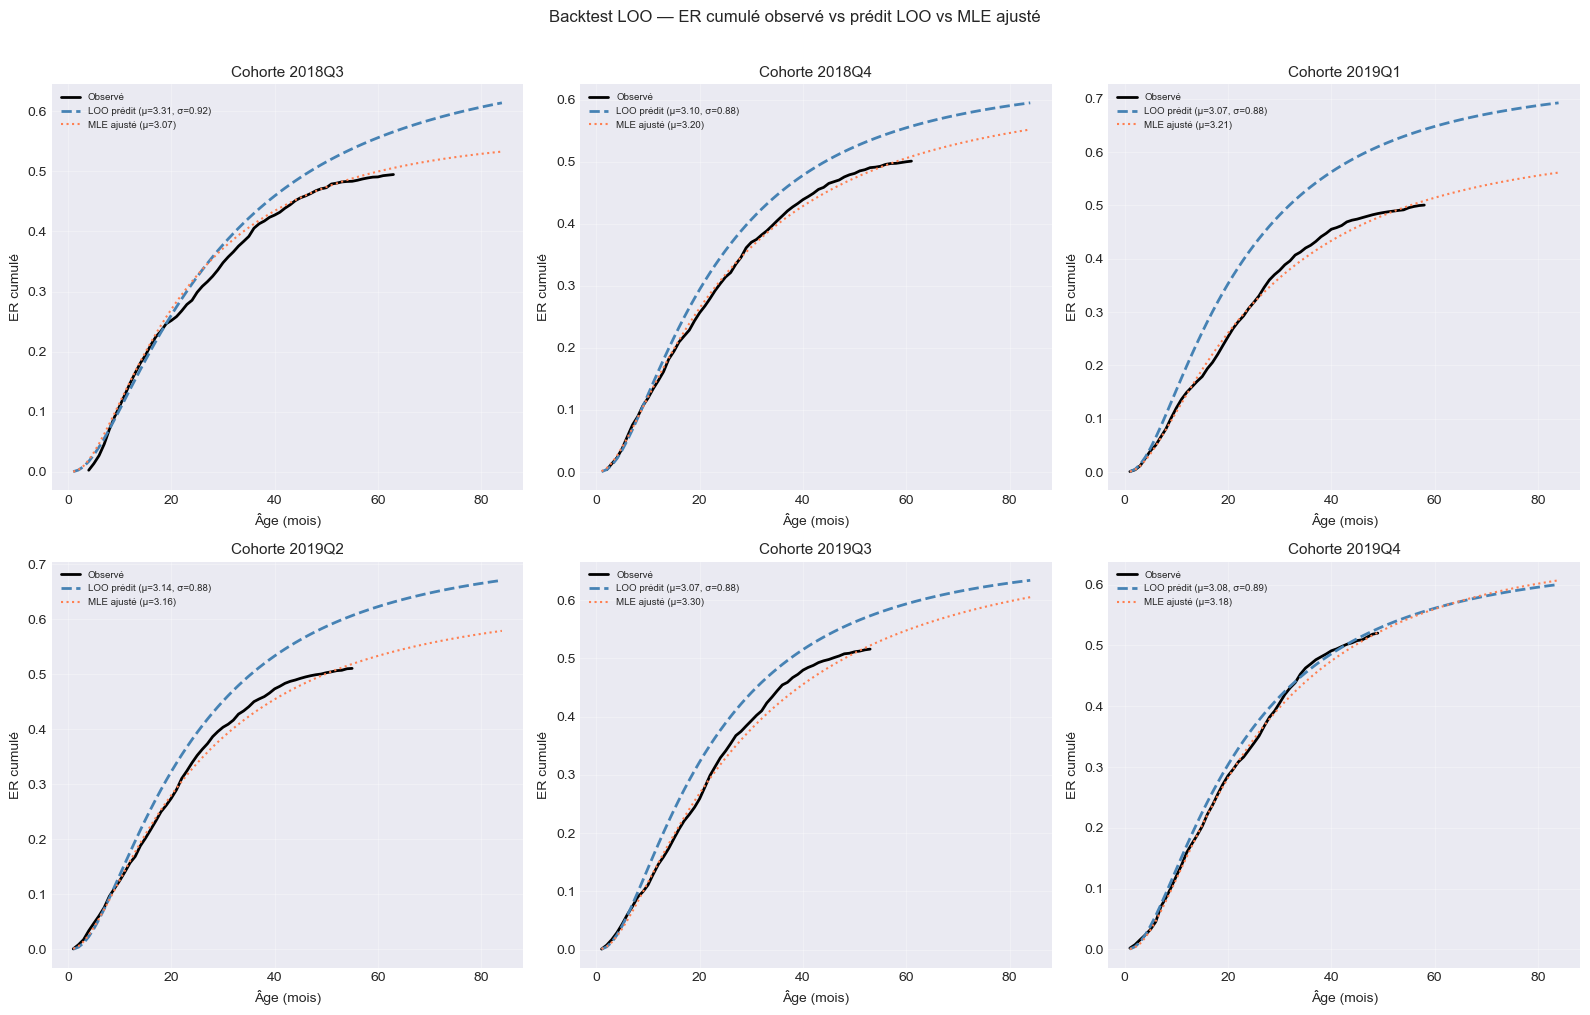

In [20]:
t_range = np.arange(1, MAX_AGE + 1, dtype=float)

def reconstruct_curve(A, mu, sigma, t_range):
    er_marg = lognorm_curve(t_range, A, mu, sigma)
    er_cum  = np.cumsum(er_marg)
    return er_marg, er_cum


# Courbes observées
ra_cum = (
    ra_agg.sort_values(["Cohorte", "AGE_PRET"])
    .assign(ER_cum=lambda d: d.groupby("Cohorte")["ER_marg"].cumsum())
)

# On utilise les prédictions LOO pour avoir une évaluation honnête sur toutes les cohortes
# Pour chaque cohorte, la prédiction LOO = prédiction faite sans cette cohorte dans le train
records = []
n_plots = min(len(df_model), 6)
sample_cohs = list(df_model.index)[:n_plots]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, coh in enumerate(sample_cohs):
    ax = axes[i]

    # Paramètres LOO prédits
    A_pred   = max(float(loo_dfs["A"].loc[coh, "y_pred"]), 1e-6)
    mu_pred  = np.clip(float(loo_dfs["mu"].loc[coh, "y_pred"]), np.log(1), np.log(MAX_AGE))
    sig_pred = np.clip(float(loo_dfs["sigma"].loc[coh, "y_pred"]), 0.1, 3.0)

    # Paramètres MLE ajustés
    A_fit   = df_params.loc[coh, "A"]
    mu_fit  = df_params.loc[coh, "mu"]
    sig_fit = df_params.loc[coh, "sigma"]

    _, er_cum_pred = reconstruct_curve(A_pred, mu_pred, sig_pred, t_range)
    _, er_cum_fit  = reconstruct_curve(A_fit, mu_fit, sig_fit, t_range)

    obs = ra_cum[ra_cum["Cohorte"] == coh][["AGE_PRET", "ER_cum"]]
    obs = obs[obs["AGE_PRET"] <= MAX_AGE]

    ax.plot(obs["AGE_PRET"], obs["ER_cum"],
            color="black", linewidth=2, label="Observé")
    ax.plot(t_range, er_cum_pred,
            color="steelblue", linewidth=2, linestyle="--",
            label=f"LOO prédit (μ={mu_pred:.2f}, σ={sig_pred:.2f})")
    ax.plot(t_range, er_cum_fit,
            color="coral", linewidth=1.5, linestyle=":",
            label=f"MLE ajusté (μ={mu_fit:.2f})")

    ax.set_title(f"Cohorte {coh}", fontsize=11)
    ax.set_xlabel("Âge (mois)")
    ax.set_ylabel("ER cumulé")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # Métriques
    for _, row in obs.iterrows():
        t = row["AGE_PRET"]
        idx_t = int(t) - 1
        if 0 <= idx_t < len(er_cum_pred):
            records.append({
                "Cohorte": coh, "Age": t,
                "y_true": row["ER_cum"],
                "y_pred_loo": er_cum_pred[idx_t],
                "y_fit_mle": er_cum_fit[idx_t]
            })

plt.suptitle("Backtest LOO — ER cumulé observé vs prédit LOO vs MLE ajusté",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


=== COMPARAISON COMPLÈTE DES MODÈLES ===
Modèle                                           R²        MAE       RMSE      Biais
--------------------------------------------------------------------------
NB3 — MLE ajusté (borne sup théorique)       0.9950   0.008935          —          —
NB3 — Ridge LOO (évaluation honnête)         0.8849   0.042638   0.054609   0.041345
NB1 — Chain Ladder (référence)               0.2531     0.1051     0.1118    -0.1031

Note : l'écart MLE ajusté vs Ridge LOO mesure la perte due à la régression.
       Si cet écart est faible : les 3 features suffisent bien.
       Si cet écart est fort : il manque une variable explicative (ex. taux OAT).


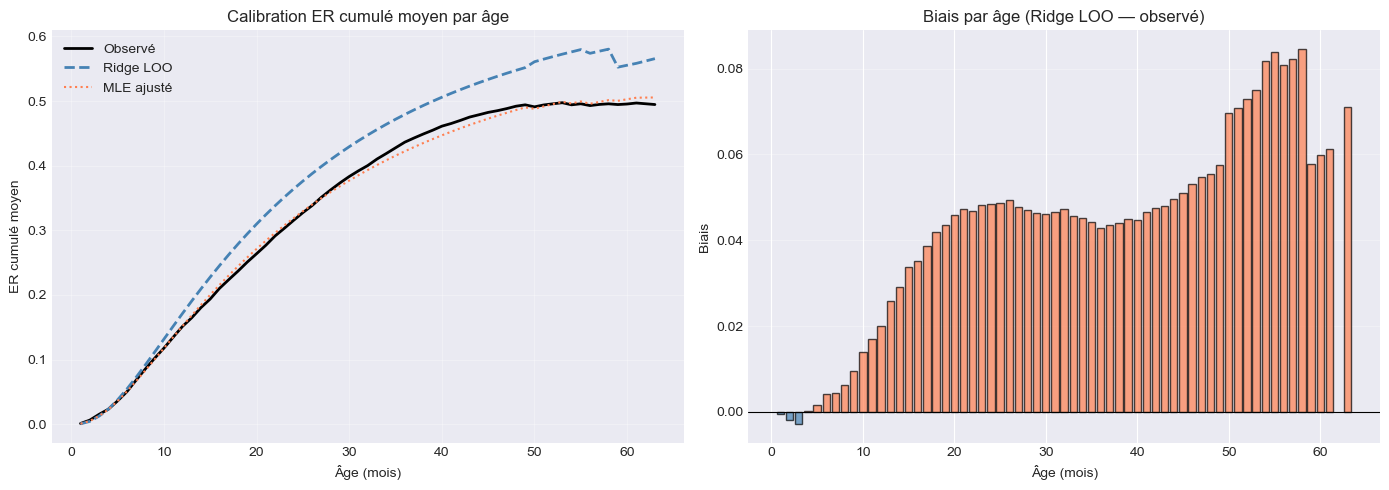

In [21]:
df_eval = pd.DataFrame(records).dropna(subset=["y_true", "y_pred_loo"])

if len(df_eval) >= 10:
    r2_loo  = r2_score(df_eval["y_true"], df_eval["y_pred_loo"])
    mae_loo = mean_absolute_error(df_eval["y_true"], df_eval["y_pred_loo"])
    rmse_loo = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred_loo"]))
    bias_loo = (df_eval["y_pred_loo"] - df_eval["y_true"]).mean()

    r2_mle  = r2_score(df_eval["y_true"], df_eval["y_fit_mle"])
    mae_mle = mean_absolute_error(df_eval["y_true"], df_eval["y_fit_mle"])

    print("=== COMPARAISON COMPLÈTE DES MODÈLES ===")
    print(f"{'Modèle':<42} {'R²':>8} {'MAE':>10} {'RMSE':>10} {'Biais':>10}")
    print("-" * 74)
    print(f"{'NB3 — MLE ajusté (borne sup théorique)':<42} {r2_mle:>8.4f} {mae_mle:>10.6f} {'—':>10} {'—':>10}")
    print(f"{'NB3 — Ridge LOO (évaluation honnête)':<42} {r2_loo:>8.4f} {mae_loo:>10.6f} {rmse_loo:>10.6f} {bias_loo:>10.6f}")
    print(f"{'NB1 — Chain Ladder (référence)':<42} {'0.2531':>8} {'0.1051':>10} {'0.1118':>10} {'-0.1031':>10}")
    print()
    print("Note : l'écart MLE ajusté vs Ridge LOO mesure la perte due à la régression.")
    print("       Si cet écart est faible : les 3 features suffisent bien.")
    print("       Si cet écart est fort : il manque une variable explicative (ex. taux OAT).")

    # Calibration par age
    cal = df_eval.groupby("Age").agg(
        obs_mean=("y_true", "mean"),
        pred_mean=("y_pred_loo", "mean"),
        mle_mean=("y_fit_mle", "mean")
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(cal["Age"], cal["obs_mean"], color="black", linewidth=2, label="Observé")
    axes[0].plot(cal["Age"], cal["pred_mean"], color="steelblue", linewidth=2,
                 linestyle="--", label="Ridge LOO")
    axes[0].plot(cal["Age"], cal["mle_mean"], color="coral", linewidth=1.5,
                 linestyle=":", label="MLE ajusté")
    axes[0].set_title("Calibration ER cumulé moyen par âge")
    axes[0].set_xlabel("Âge (mois)")
    axes[0].set_ylabel("ER cumulé moyen")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    bias_by_age = cal["pred_mean"] - cal["obs_mean"]
    axes[1].bar(cal["Age"], bias_by_age, color=["coral" if b > 0 else "steelblue" for b in bias_by_age],
                edgecolor="black", alpha=0.7)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Biais par âge (Ridge LOO — observé)")
    axes[1].set_xlabel("Âge (mois)")
    axes[1].set_ylabel("Biais")
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


**Lecture du tableau comparatif**

Le tableau présente trois niveaux de performance :

1. **MLE ajusté** : borne supérieure théorique du modèle log-normal. C'est ce qu'on obtiendrait si on connaissait parfaitement les paramètres de chaque cohorte. Si ce R² est faible (< 0.5), le modèle log-normal est mal spécifié — les courbes observées ne sont pas log-normales.

2. **Ridge prédit** : performance réelle hors-échantillon. L'écart avec le MLE ajusté mesure la perte due à la régression des paramètres — autrement dit, la qualité avec laquelle les covariables cohorte expliquent les paramètres.

3. **Chain Ladder (NB1)** : référence. Si le NB3 Ridge ne bat pas le NB1, c'est que les covariables individuelles n'apportent pas d'information au-delà de la structure temporelle brute.

## 6. Analyse de sensibilité — effet des covariables sur la forme de la courbe

On illustre comment les trois paramètres se traduisent en termes de courbes ER cumulées, pour différentes valeurs des covariables clés. C'est le type de résultat directement interprétable dans un mémoire.

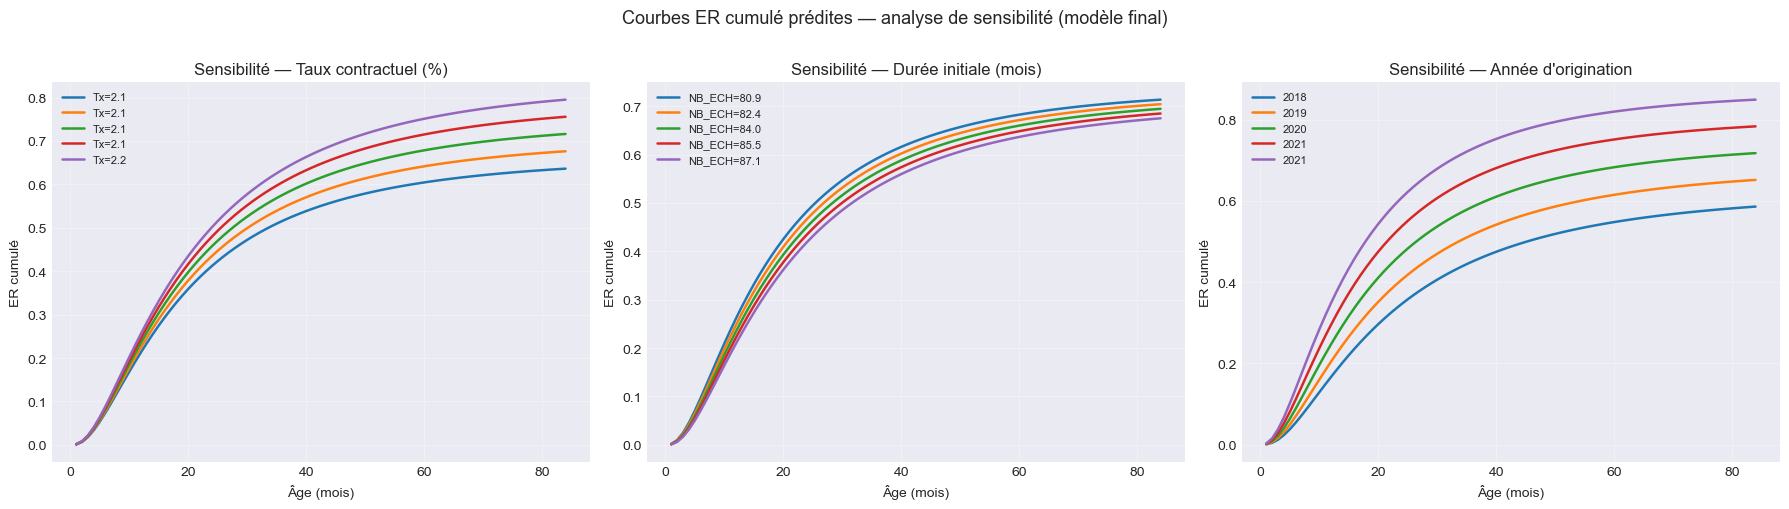

In [22]:
median_profile = X_all.median()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (feat, feat_label) in zip(axes, [
    ("Tx", "Taux contractuel (%)"),
    ("NB_ECH", "Durée initiale (mois)"),
    ("annee_orig", "Année d'origination")
]):
    vals = np.linspace(
        df_model[feat].quantile(0.1),
        df_model[feat].quantile(0.9), 5
    )
    for v in vals:
        profile = median_profile.copy()
        profile[feat] = v
        A_p   = max(regressors_final["A"].predict([profile])[0], 1e-6)
        mu_p  = np.clip(regressors_final["mu"].predict([profile])[0], np.log(1), np.log(MAX_AGE))
        sig_p = np.clip(regressors_final["sigma"].predict([profile])[0], 0.1, 3.0)
        _, er_cum = reconstruct_curve(A_p, mu_p, sig_p, t_range)
        label = f"{feat}={v:.1f}" if feat != "annee_orig" else f"{int(v)}"
        ax.plot(t_range, er_cum, label=label, linewidth=1.8)

    ax.set_title(f"Sensibilité — {feat_label}")
    ax.set_xlabel("Âge (mois)")
    ax.set_ylabel("ER cumulé")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Courbes ER cumulé prédites — analyse de sensibilité (modèle final)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 7. Synthèse des trois modèles et recommandations

### Tableau récapitulatif

| Critère | NB1 Chain Ladder | NB2 Multiplicatif | NB3 Log-normal |
|---|---|---|---|
| Prévision hors-échantillon | Non | Partielle | Oui |
| Utilise les covariables | Non | Oui (niveau) | Oui (niveau + forme) |
| Interprétabilité économique | Faible | Moyenne | Forte |
| Nombre de paramètres | Nb facteurs | 1 (δ) | 3 (A, μ, σ) |
| Hypothèse de forme temporelle | Aucune | g(t) fixe | Log-normale |
| Robustesse (peu de cohortes) | Bonne | Bonne | Fragile si n < 20 cohortes |

### Résultat principal pour le mémoire

La progression NB1 → NB2 → NB3 montre qu'on peut améliorer la prévision hors-échantillon en intégrant progressivement les caractéristiques individuelles des cohortes. La limite commune des trois modèles est l'**absence d'une variable exogène de taux de marché** : sur des crédits conso, l'effet taux est moins dominant qu'en immobilier, mais l'année d'origination (proxy du cycle économique) ressort systématiquement comme variable importante.

### Extension prioritaire

Joindre le **taux moyen des crédits conso nouveaux** (Banque de France, série mensuelle publique) pour calculer le spread $Tx_{pret} - Tx_{marche}$ au moment de l'observation. Ce spread est le déterminant théorique du RA et sa mise à disposition transformerait le NB2 et le NB3 en modèles dynamiques capables de réagir aux changements de conditions de marché.